#House Price Prediction (Mutliple Linear Regression)


# Dataset Columns

House_Price → Target variable (price of the house)

Size_sqft → Size of the house in square feet

Bedrooms → Number of bedrooms

Age_years → Age of the house

Distance_to_City_km → Distance from city center (in km)

Garage_Size → Number of garage spaces


# Step:1 Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#Step:2 Load the Dataset

In [ ]:
df = pd.read_csv('/content/house_price_regression_dataset.csv')
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


In [ ]:
df.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


# Data Information

In [ ]:
df

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06
...,...,...,...,...,...,...,...,...
995,3261,4,1,1978,2.165110,2,10,7.014940e+05
996,3179,1,2,1999,2.977123,1,10,6.837232e+05
997,2606,4,2,1962,4.055067,0,2,5.720240e+05
998,4723,5,2,1950,1.930921,0,7,9.648653e+05


In [ ]:
#type of dataset
type(df)

pandas.core.frame.DataFrame

In [ ]:
df.tail()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
995,3261,4,1,1978,2.165110,2,10,701493.997069
996,3179,1,2,1999,2.977123,1,10,683723.160704
997,2606,4,2,1962,4.055067,0,2,572024.023634
998,4723,5,2,1950,1.930921,0,7,964865.298639
999,3268,4,2,1983,3.108790,2,2,742599.253332


In [ ]:
df.shape

(1000, 8)

In [ ]:
df.isnull()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False,False
996,False,False,False,False,False,False,False,False
997,False,False,False,False,False,False,False,False
998,False,False,False,False,False,False,False,False


In [ ]:
df.isnull().sum()

,0
Square_Footage,0
Num_Bedrooms,0
Num_Bathrooms,0
Year_Built,0
Lot_Size,0
Garage_Size,0
Neighborhood_Quality,0
House_Price,0


In [ ]:
#null rows drop
df.dropna()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06
...,...,...,...,...,...,...,...,...
995,3261,4,1,1978,2.165110,2,10,7.014940e+05
996,3179,1,2,1999,2.977123,1,10,6.837232e+05
997,2606,4,2,1962,4.055067,0,2,5.720240e+05
998,4723,5,2,1950,1.930921,0,7,9.648653e+05


#Exploratory Data Analysis
Univariant Analysis

House_Price(Target Variable)

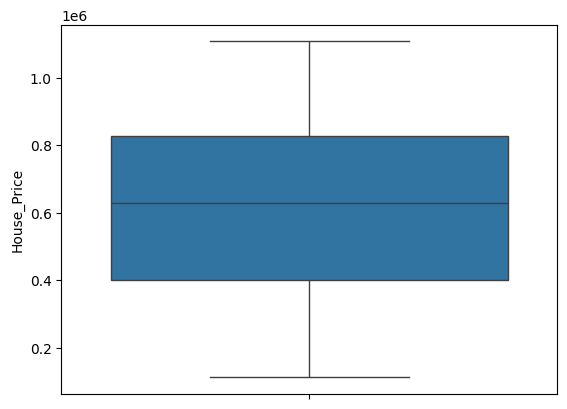

In [ ]:
import seaborn as sns
sns.boxplot(df['House_Price'])
plt.show()

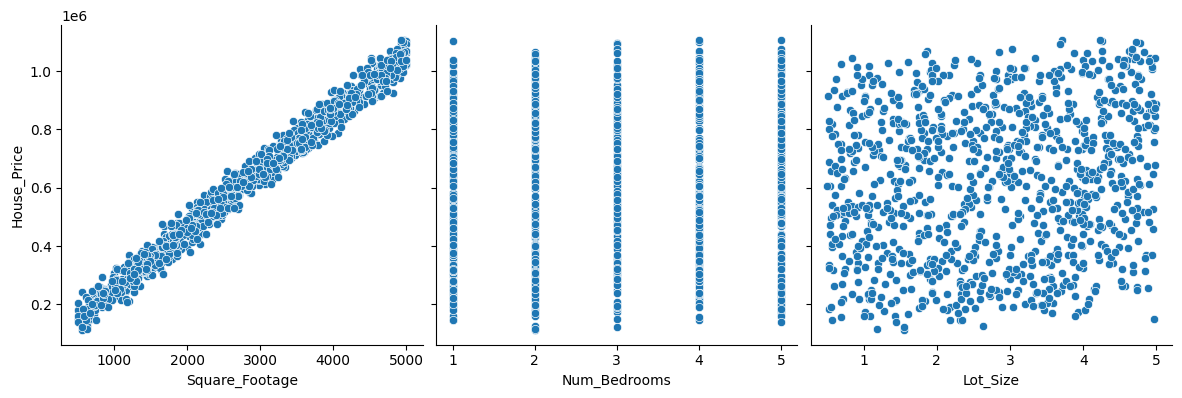

In [ ]:
# Let's see how House_Price are related with other variables using scatter plot.
sns.pairplot(df,
             x_vars=['Square_Footage', 'Num_Bedrooms', 'Lot_Size'],
             y_vars='House_Price',
             height=4,
             aspect=1,
             kind='scatter')

plt.show()

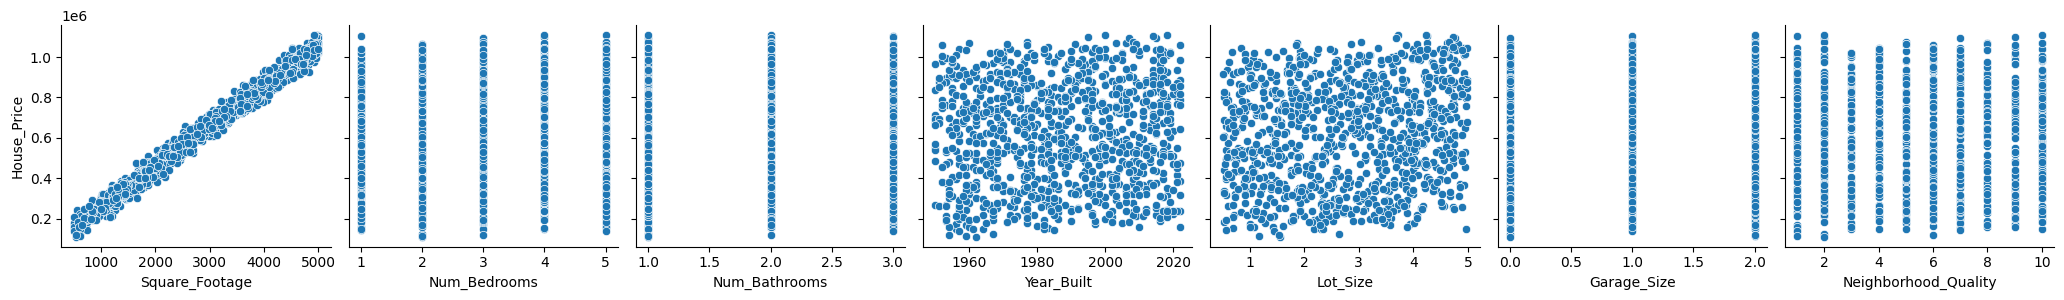

In [ ]:
#for all features
sns.pairplot(df,
             x_vars=['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms',
                     'Year_Built', 'Lot_Size', 'Garage_Size',
                     'Neighborhood_Quality'],
             y_vars='House_Price',
             height=3,
             aspect=1,
             kind='scatter')

plt.show()


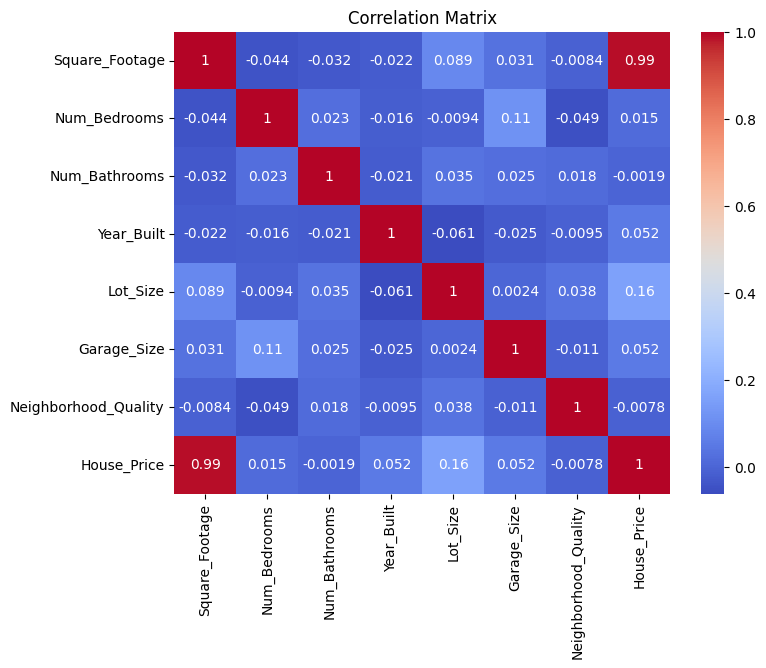

In [ ]:
#Lets see the corelation between different variables
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

#Relationship between Square_Footage and House_Price

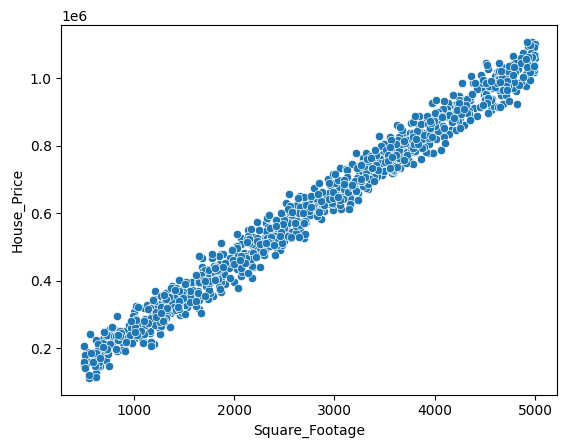

In [ ]:
sns.scatterplot(x="Square_Footage", y="House_Price", data=df)
plt.show()

#Step 3: Define Variables
Target Variable


In [ ]:
y = df["House_Price"]

Features

In [ ]:
df.columns

Index(['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price'],
      dtype='object')

In [ ]:
X = df[['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality']]

#Step 4: Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Step 5: Train Linear Regression Model

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

#Step:6 Interpret Co efficient

In [ ]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,Square_Footage,199.513245
1,Num_Bedrooms,10225.204424
2,Num_Bathrooms,8208.434778
3,Year_Built,993.537171
4,Lot_Size,14885.384415
5,Garage_Size,5146.148383
6,Neighborhood_Quality,115.068595


In [ ]:
print("Slope (m):", model.coef_[0])
print("Intercept (c):", model.intercept_)

Slope (m): 199.51324510306222
Intercept (c): -2010567.4202702101


#Step:7 Make Predictions

In [ ]:
y_pred = model.predict(X_test)
print(y_pred)

[ 868687.10747903  490337.89825447  945667.12422537 1033402.87599247
  776698.77390587  732444.09335308  995051.99156272  885174.76924362
  796730.53817137  931741.09209272  759486.73376772  645409.40410205
  217706.20688729 1047436.52669427  536985.283711    187868.55343105
  456819.02346557  357933.98497768  743138.35721931  362670.94796792
  775101.05248527  478174.42921702  680966.06345079  889457.56001471
  447158.93387226  396997.78641332  454334.22026962  442837.53540887
  187336.81096629  491668.18070411  279715.81740979  895941.0005743
  783583.19778842  352212.91737968  479313.284656    766612.6601435
  474636.25109508  572446.37288032  303449.70619643  154599.27036073
  304341.05092125  299677.00775284  508575.91105888  309977.51725285
 1082131.76994762 1011343.63575232  760359.56460958  807425.57445877
 1025548.17009414  692212.56393101  282589.94240716  753107.78598704
  812615.71007891  717618.32372696  542152.84832665  802743.49807682
  174572.00320684  331617.63053122  

#Step:8 Modal Evaluation

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 8174.583600008702
MSE: 101434798.50566778
R2 Score: 0.9984263636823408


#Visualization Regression Line

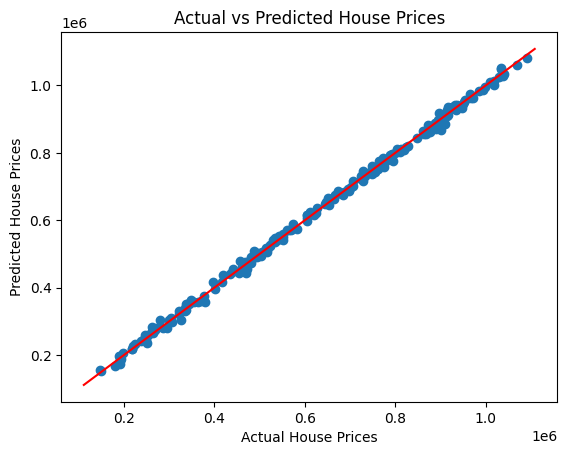

In [ ]:
plt.scatter(y_test, y_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color="red")
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()

#Step 10: Identify Most Influential Feature

In [ ]:
coefficients["Absolute"] = abs(coefficients["Coefficient"])
coefficients.sort_values("Absolute", ascending=False)

,Feature,Coefficient,Absolute
4,Lot_Size,14885.384415,14885.384415
1,Num_Bedrooms,10225.204424,10225.204424
2,Num_Bathrooms,8208.434778,8208.434778
5,Garage_Size,5146.148383,5146.148383
3,Year_Built,993.537171,993.537171
0,Square_Footage,199.513245,199.513245
6,Neighborhood_Quality,115.068595,115.068595


In [ ]:
new_house = [[2000,   # Square_Footage
              3,      # Num_Bedrooms
              2,      # Num_Bathrooms
              2015,   # Year_Built
              5000,   # Lot_Size
              2,      # Garage_Size
              4]]     # Neighborhood_Quality

predicted_price = model.predict(new_house)

print("Predicted House Price:", predicted_price[0])

NameError: name 'model' is not defined

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

NameError: name 'LinearRegression' is not defined

In [ ]:
new_house = [[2000,   # Square_Footage
              3,      # Num_Bedrooms
              2,      # Num_Bathrooms
              2015,   # Year_Built
              5000,   # Lot_Size
              2,      # Garage_Size
              4]]     # Neighborhood_Quality

predicted_price = model.predict(new_house)

print("Predicted House Price:", predicted_price[0])

NameError: name 'model' is not defined